<a href="https://colab.research.google.com/github/rafaellopesdesa/hnsbi-toolkit/blob/main/examples/notebooks/hybrid_reference_flow_and_density_ratios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Native reference flow and density ratios

It trains a normalized reference flow $q_\phi(x)$ and arithmetic density-ratio ensembles

$$
\widehat r_k(x)=\frac{p_k(x)}{q_\phi(x)},\qquad
\widehat p_k(x)=q_\phi(x)\frac{\widehat r_k(x)}
{E_{q_\phi}[\widehat r_k]}.
$$

The notebook now reproduces the earlier visual validation chain: reference-flow closure, independent ensemble calibration and reweighting, weighted-reference pair closure, analytical density truth, nominal likelihood closure, and the full systematics-profiled workspace scan. Generic flow/ratio diagnostics come from `hnsbi`; analytical truth remains example-local because it is unavailable for a general user dataset.


In [1]:
import importlib
from importlib.metadata import PackageNotFoundError, version as installed_version
from pathlib import Path
import os, signal, subprocess, sys

def distribution_version(name):
    try:
        return installed_version(name)
    except PackageNotFoundError:
        return None

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    loaded_versions = {
        name: getattr(sys.modules.get(name), '__version__', None)
        for name in ('numpy', 'jax', 'jaxlib')
    }
    jax_was_loaded = any(
        name == 'jax' or name.startswith(('jax.', 'jaxlib', 'jax_plugins'))
        for name in sys.modules
    )
    ROOT = Path('/content/drive/MyDrive/hsbi-toolkit')
    REPO = ROOT / 'hnsbi-toolkit'
    ROOT.mkdir(parents=True, exist_ok=True)
    if not (REPO / '.git').is_dir():
        subprocess.run(['git', 'clone', 'https://github.com/rafaellopesdesa/hnsbi-toolkit.git', str(REPO)], check=True)
    else:
        subprocess.run(['git', '-C', str(REPO), 'fetch', 'origin', 'main'], check=True)
        subprocess.run(['git', '-C', str(REPO), 'checkout', 'main'], check=True)
        subprocess.run(['git', '-C', str(REPO), 'pull', '--ff-only', 'origin', 'main'], check=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-e', f'{REPO}[lhc,flows]'], check=True)

    # Colab installs JAX's CUDA plugin separately from jaxlib. If an
    # earlier dependency resolution changed jaxlib, realign the plugin
    # before JAX discovers it; mixed PJRT versions fail at execution.
    jaxlib_version = distribution_version('jaxlib')
    plugin_extras = {
        'jax-cuda12-plugin': 'cuda12-local',
        'jax-cuda13-plugin': 'cuda13-local',
    }
    repaired_plugins = []
    for plugin, extra in plugin_extras.items():
        plugin_version = distribution_version(plugin)
        if plugin_version is not None and plugin_version != jaxlib_version:
            print(f'Aligning {plugin} {plugin_version} with jaxlib {jaxlib_version}.')
            subprocess.run(
                [sys.executable, '-m', 'pip', 'install', '-q', '--upgrade',
                 f'jax[{extra}]=={jaxlib_version}'],
                check=True,
            )
            if distribution_version(plugin) != jaxlib_version:
                raise RuntimeError(f'Could not align {plugin} with jaxlib.')
            repaired_plugins.append(plugin)

    changed_loaded_packages = [
        name for name, loaded in loaded_versions.items()
        if loaded is not None and loaded != distribution_version(name)
    ]
    if changed_loaded_packages or (repaired_plugins and jax_was_loaded):
        reasons = changed_loaded_packages + repaired_plugins
        print(
            f'Updated {", ".join(dict.fromkeys(reasons))}. '
            'Restarting the Colab runtime once to load a consistent NumPy/JAX stack. '
            'After it reconnects, run this setup cell again.',
            flush=True,
        )
        os.kill(os.getpid(), signal.SIGKILL)
else:
    REPO = Path.cwd()
    if not (REPO / 'pyproject.toml').exists():
        REPO = Path.cwd().parents[1]
os.chdir(REPO)
source_root = (REPO / 'src').resolve()
expected_hnsbi = source_root / 'hnsbi' / '__init__.py'
notebook_helpers = str((REPO / 'examples' / 'notebooks').resolve())
if notebook_helpers not in sys.path:
    # Append so the LHC example's generate_distributions.py remains canonical.
    sys.path.append(notebook_helpers)
for import_dir in (source_root, REPO / 'examples' / 'lhc_analysis'):
    import_path = str(import_dir.resolve())
    if import_path not in sys.path:
        sys.path.insert(0, import_path)

# An editable install writes a .pth file, but the running interpreter does
# not process a newly created .pth until its next start. Remove any namespace
# placeholder cached before the source tree became importable.
loaded_hnsbi = sys.modules.get('hnsbi')
loaded_file = getattr(loaded_hnsbi, '__file__', None)
if loaded_hnsbi is not None and (
    loaded_file is None or Path(loaded_file).resolve() != expected_hnsbi
):
    for module_name in tuple(sys.modules):
        if module_name == 'hnsbi' or module_name.startswith('hnsbi.'):
            sys.modules.pop(module_name, None)
importlib.invalidate_caches()
hnsbi_package = importlib.import_module('hnsbi')
actual_hnsbi = Path(hnsbi_package.__file__).resolve()
if actual_hnsbi != expected_hnsbi or not hasattr(hnsbi_package, 'Project'):
    raise ImportError(
        f'Expected hnsbi with Project from {expected_hnsbi}, got {actual_hnsbi}'
    )
print(REPO)


Mounted at /content/drive
/content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit


## Generate the configured samples

The shared generator supplies signal, background, and the balanced reference sample, together with response, resolution, and signal-theory variations. It also performs the legacy-equivalent preselection once, writes `*_presel.parquet` copies, and records the fixed cut and selected yields in a checksummed manifest. The notebook therefore begins directly with the hNSBI methods. The latent Gaussian-mixture parameters are retained so this controlled example can be checked against analytical conditional densities.


In [2]:
from generate_distributions import generate, nominal_preselection_selector
from hnsbi import Project
from preselection import (
    PreselectionConfig,
    load_preselection_manifest,
    verify_preselection_manifest,
)

EXAMPLE = REPO / 'examples' / 'lhc_analysis'
REQUESTED_EVENTS = {
    'signal': 500_000,
    'background': 2_000_000,
    'reference': 200_000,
}
generate(
    EXAMPLE / 'data',
    signal_events=REQUESTED_EVENTS['signal'],
    background_events=REQUESTED_EVENTS['background'],
    reference_events=REQUESTED_EVENTS['reference'],
)
manifest_ok, manifest_reasons = verify_preselection_manifest(
    EXAMPLE / 'data',
    requested_events=REQUESTED_EVENTS,
    generation_seed=20260727,
    config=PreselectionConfig(),
    selector_fingerprint=nominal_preselection_selector().fingerprint,
)
if not manifest_ok:
    raise RuntimeError('; '.join(manifest_reasons))
PRESELECTION = load_preselection_manifest(EXAMPLE / 'data')
project = Project.load(EXAMPLE / 'analysis.yaml')
FEATURES = tuple(project.config.features)
ANALYSIS_YIELDS = project.resolved_nominal_yields()
print('features:', FEATURES)
print('preselection cut:', PRESELECTION['cut'])
print('selected yields:', ANALYSIS_YIELDS)


features: ('x1', 'x2', 'x3', 'x4', 'x5')
preselection cut: {'background_to_signal': 249.98155864586724, 'background_yield': 154796.30635524172, 'log_ratio_cut': 0.740000000000002, 'ratio': 2.0959355144943688, 'signal_yield': 619.2309032464738}
selected yields: {'signal': 619.2309032465998, 'background': 154796.30635524166}


## Train the reference and native ratio ensembles

Each ratio member has independent class normalization, deterministic train/validation/holdout provenance, embedded preprocessing in ONNX, parity checks, and loss/overtraining diagnostics. After the ensemble is trained, `Project.train_ratios` uses the common untouched target `holdout` split plus a fresh reference-flow sample for the ensemble calibration and reweighting figures displayed below.


In [3]:
from utils_lhc_validation import write_reuse_provenance

reference_artifacts = project.train_reference()
reference = reference_artifacts.training.flow
ratio_artifacts = project.train_ratios(
    reference,
    normalization_events=40_000,
    seed=20260729,
)
for sample, training in ratio_artifacts.training.items():
    print(sample, training.manifest_path)
    print(training.members[0].metadata.get('diagnostics'))

nominal_data = {
    sample: EXAMPLE / 'data' / f'{sample}_presel.parquet'
    for sample in ('signal', 'background', 'reference')
}
nominal_data['preselection-manifest'] = (
    EXAMPLE / 'data' / 'preselection.manifest.json'
)
nominal_artifacts = {
    'reference': reference_artifacts.checkpoint_manifest,
    'ratio-signal': ratio_artifacts.training['signal'].manifest_path,
    'ratio-background': ratio_artifacts.training['background'].manifest_path,
    'normalizer': ratio_artifacts.normalizer_manifest,
}
nominal_provenance = write_reuse_provenance(
    EXAMPLE / 'artifacts' / 'nominal_training_provenance.json',
    configuration_path=EXAMPLE / 'analysis.yaml',
    data_paths=nominal_data,
    artifact_paths=nominal_artifacts,
    metadata={
        'features': list(FEATURES),
        'requested_rows': REQUESTED_EVENTS,
        'selected_rows': {
            sample: PRESELECTION['samples'][sample]['selected_events']
            for sample in ('signal', 'background')
        } | {'reference': PRESELECTION['reference']['selected_events']},
    },
)
print('reusable nominal bundle:', nominal_provenance)

signal /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/ratios/signal/ratio_ensemble.manifest.json
{'loss': {'epochs': 22, 'best_validation_loss': 0.6878159046173096, 'final_training_loss': 0.6878335475921631}, 'classification': {'holdout_auc': 0.5540451003204925}, 'overtraining': {'numerator_weighted_ks': 0.010053106759916164, 'denominator_weighted_ks': 0.006513521907580366}, 'calibration': {'brier_score': 0.24767742587962113, 'expected_calibration_error': 0.0044166709428507854, 'training_brier_score': 0.24742593452298614, 'training_expected_calibration_error': 0.0018382177020388189, 'holdout_log_ratio_weighted_rmse': 0.0821334817255146, 'training_log_ratio_weighted_rmse': 0.05070508455882227}, 'ratio_tails': {'training': {'minimum': 0.3934221788140453, 'maximum': 1.8920676370206684, 'p001': 0.6484292754810291, 'p999': 1.8205430716094442}, 'holdout': {'minimum': 0.409465067093915, 'maximum': 1.8753276762630213, 'p001': 0.6383210481544541, 'p999': 1.808

## Reference-flow closure

The pair plot tests marginals, two-dimensional contours, and correlations; the other two figures test the learned log-density distribution and its CDF.


Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/reference_feature_correlation_closure.py


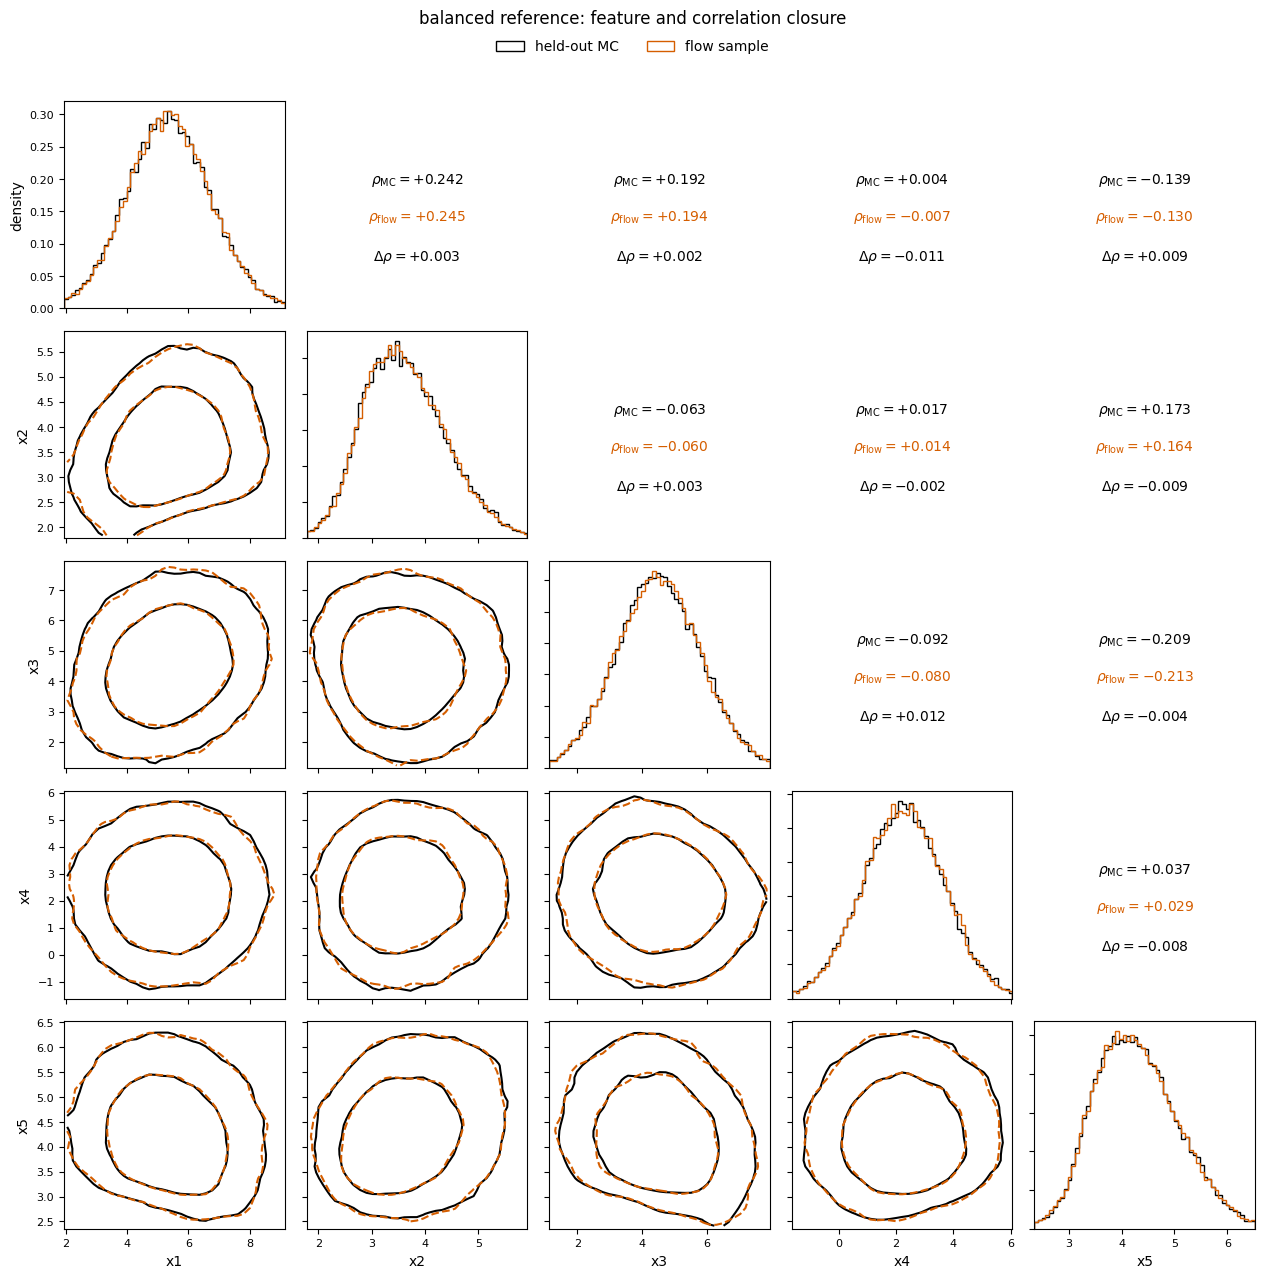

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/reference_log_density_closure.py


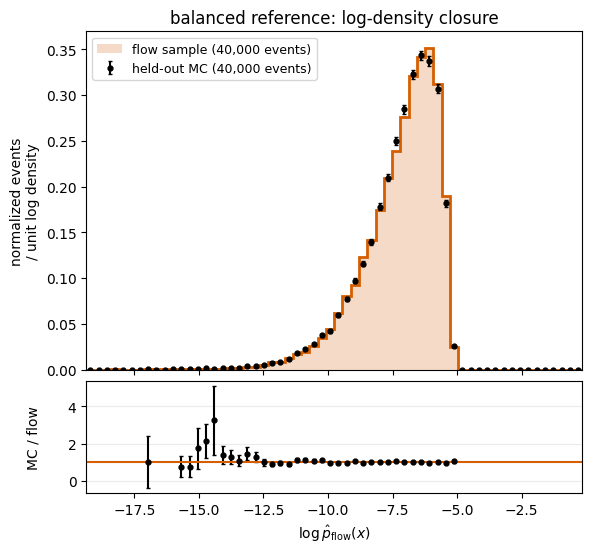

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/reference_log_density_cdf_closure.py


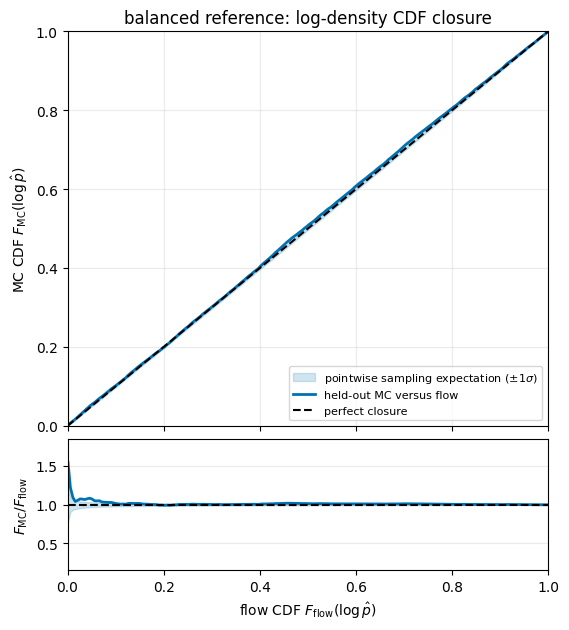

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/reference_native_feature_closure.py


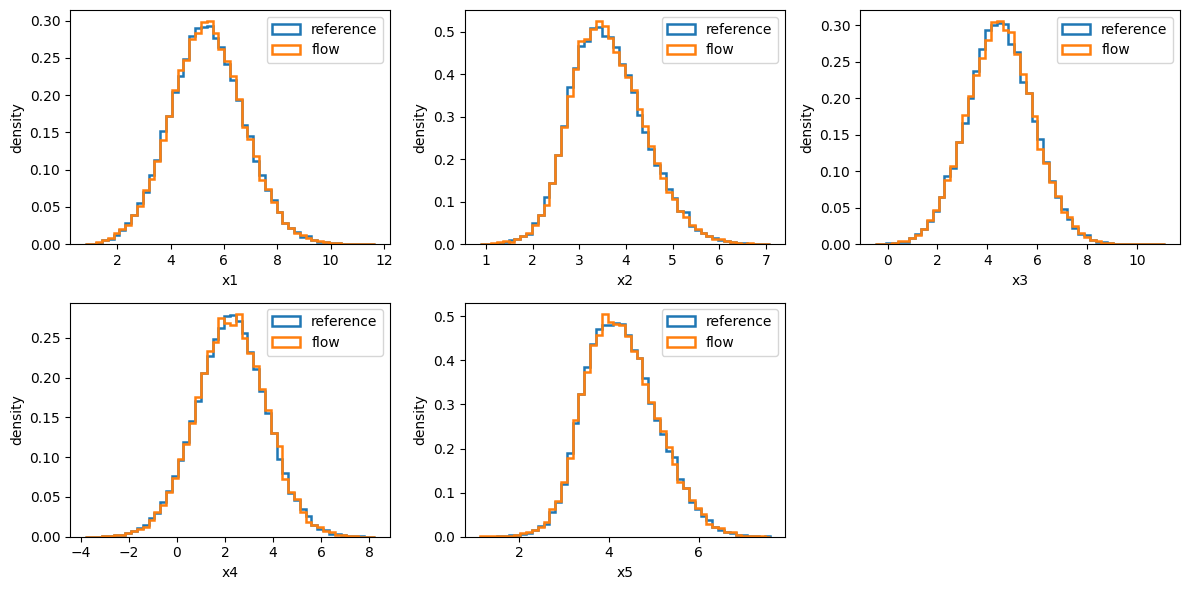

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/reference_native_correlation_closure.py


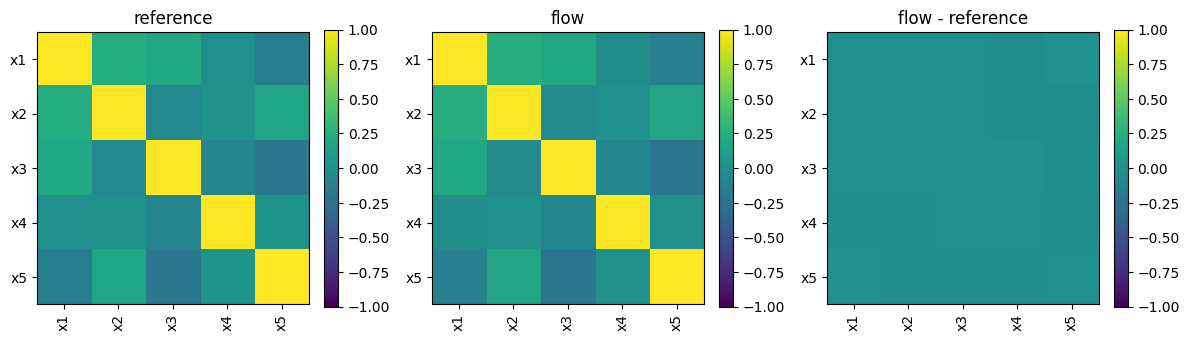

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from hnsbi.flow_diagnostics import (
    plot_correlation_closure as plot_native_correlation_closure,
    plot_feature_closure as plot_native_feature_closure,
)
from utils_plotting import (
    export_standalone_figure_script,
    plot_flow_pair_closure,
    plot_log_density_truth_binned,
    plot_log_density_truth_scatter,
    plot_log_prob_cdf_closure,
    plot_log_prob_closure,
    plot_profile_scan,
)

SIGNAL_COLOR = '#d55e00'
BACKGROUND_COLOR = '#0072b2'
FIGURE_DIR = EXAMPLE / 'artifacts' / 'notebook_figures' / 'hybrid'
FIGURE_SCRIPT_DIR = FIGURE_DIR / 'scripts'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def export_hybrid_figure(figure, name):
    figure.savefig(FIGURE_DIR / f'{name}.png', dpi=160, bbox_inches='tight')
    return export_standalone_figure_script(
        figure,
        script_name=name,
        output_dir=FIGURE_SCRIPT_DIR,
    )

flow_validation = reference_artifacts.diagnostics
fig = plot_flow_pair_closure(
    'balanced reference',
    flow_validation.reference_values,
    flow_validation.generated_values,
    FEATURES,
    mc_weights=flow_validation.reference_weights,
    generated_color=SIGNAL_COLOR,
)
export_hybrid_figure(fig, 'reference_feature_correlation_closure')
plt.show()

fig = plot_log_prob_closure(
    'balanced reference',
    flow_validation.reference_log_prob,
    flow_validation.generated_log_prob,
    flow_color=SIGNAL_COLOR,
)
export_hybrid_figure(fig, 'reference_log_density_closure')
plt.show()

fig = plot_log_prob_cdf_closure(
    'balanced reference',
    flow_validation.reference_log_prob,
    flow_validation.generated_log_prob,
    color=BACKGROUND_COLOR,
)
export_hybrid_figure(fig, 'reference_log_density_cdf_closure')
plt.show()

# The native layouts remain available as compact production diagnostics.
for name, plotter in (
    ('reference_native_feature_closure', plot_native_feature_closure),
    ('reference_native_correlation_closure', plot_native_correlation_closure),
):
    fig = plotter(flow_validation)
    export_hybrid_figure(fig, name)
    plt.show()


## Analytical truth for the reference density

For a latent Gaussian component $z\sim\mathcal N(m,\Sigma)$ and response $x=Dz+\epsilon$, the reconstructed component is

$$
x\sim\mathcal N\left(Dm,\;D\Sigma D^\mathsf{T}
+\operatorname{diag}(R^2)\right).
$$

The selected reference is generated with exactly half of its events from each conditional component, so $p_{\rm ref}^{\rm sel}(x)=\tfrac12p_S(x\mid\mathrm{pass})+\tfrac12p_B(x\mid\mathrm{pass})$. The manifest supplies the selection efficiencies needed to normalize these conditional truth densities. These truth-only transformations live in `utils_lhc_validation.py`, while the mixture definitions are imported from the exact generator used above.


reference: corr(log p)=0.9916, RMSE=0.1897, bias=-0.0189
Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/reference_log_density_truth_scatter.py


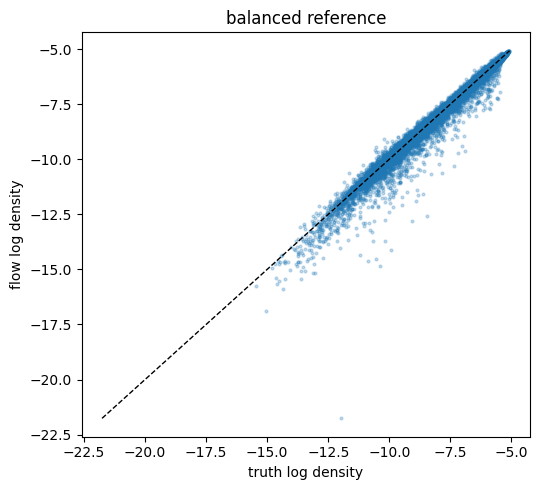

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/reference_log_density_truth_binned.py


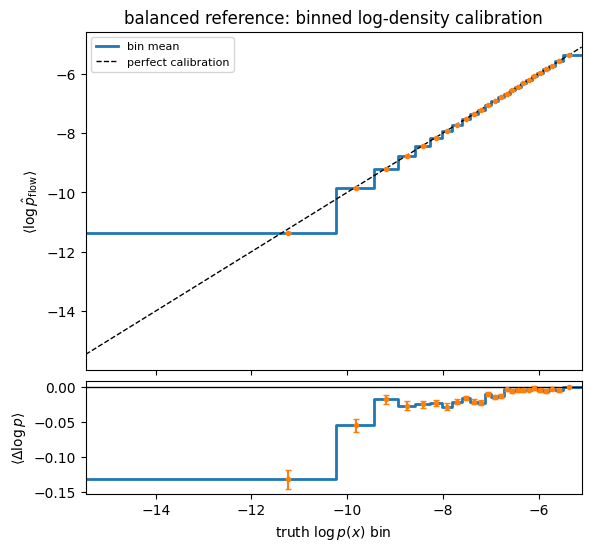

In [5]:
from generate_distributions import (
    RESOLUTION,
    SCALE,
    background_components,
    signal_components,
)
from utils_lhc_validation import (
    binned_log_density_calibration,
    conditional_log_density,
    extended_mu_scan,
    mixture_log_density,
    reconstructed_components,
    reference_log_density,
)

RECO_COMPONENTS = {
    'signal': reconstructed_components(
        signal_components(), scale=SCALE, resolution=RESOLUTION
    ),
    'background': reconstructed_components(
        background_components(), scale=SCALE, resolution=RESOLUTION
    ),
}
SELECTION_EFFICIENCIES = {
    sample: PRESELECTION['samples'][sample]['efficiency']
    for sample in ('signal', 'background')
}

reference_values = flow_validation.reference_values
truth_reference_components = {
    sample: conditional_log_density(
        mixture_log_density(reference_values, components),
        selection_efficiency=SELECTION_EFFICIENCIES[sample],
    )
    for sample, components in RECO_COMPONENTS.items()
}
truth_reference_log_density = reference_log_density(
    truth_reference_components,
    fractions={'signal': 0.5, 'background': 0.5},
)
learned_reference_log_density = reference.log_prob(reference_values)
reference_delta = learned_reference_log_density - truth_reference_log_density
print(
    'reference: '
    f'corr(log p)={np.corrcoef(truth_reference_log_density, learned_reference_log_density)[0, 1]:.4f}, '
    f'RMSE={np.sqrt(np.mean(reference_delta**2)):.4f}, '
    f'bias={np.mean(reference_delta):+.4f}'
)

fig = plot_log_density_truth_scatter(
    'balanced reference',
    truth_reference_log_density,
    learned_reference_log_density,
)
export_hybrid_figure(fig, 'reference_log_density_truth_scatter')
plt.show()

calibration, edges = binned_log_density_calibration(
    truth_reference_log_density,
    learned_reference_log_density,
)
fig = plot_log_density_truth_binned(
    'balanced reference',
    calibration,
    edges,
    truth_reference_log_density,
    learned_reference_log_density,
)
export_hybrid_figure(fig, 'reference_log_density_truth_binned')
plt.show()


## Independent ensemble calibration and reweighting

These are diagnostics of the arithmetic ensemble actually used below, rather than of one member. The validation target is the explicit common `holdout` split, untouched by every ensemble member; the denominator is a fresh post-training reference-flow sample. The calibration plot checks the classifier odds, while each feature plot checks

$$
p_k(x_j)\simeq
\frac{\widehat r_k(x)\,q_\phi(x)}
{E_{q_\phi}[\widehat r_k]}.
$$


signal {'classification': {'weighted_auc': 0.551325627047373}, 'calibration': {'brier_score': 0.24790087717388407, 'expected_calibration_error': 0.005705027600804208, 'log_ratio_weighted_rmse': 0.07759534246290664, 'log_ratio_occupied_mass': 0.9999999999999997}, 'normalization': {'reference_mean_ratio': 0.9986291641033094, 'reference_mean_standard_error': 0.001999812248055738, 'reference_effective_events': 11186.000000000002, 'deployed_normalization': 1.0055625971454722}, 'validation': {'reference_count': 11186, 'source': 'explicit-target-holdout-and-fresh-reference-flow', 'target_count': 11186}}
Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/signal_reference_ratio_calibration.py


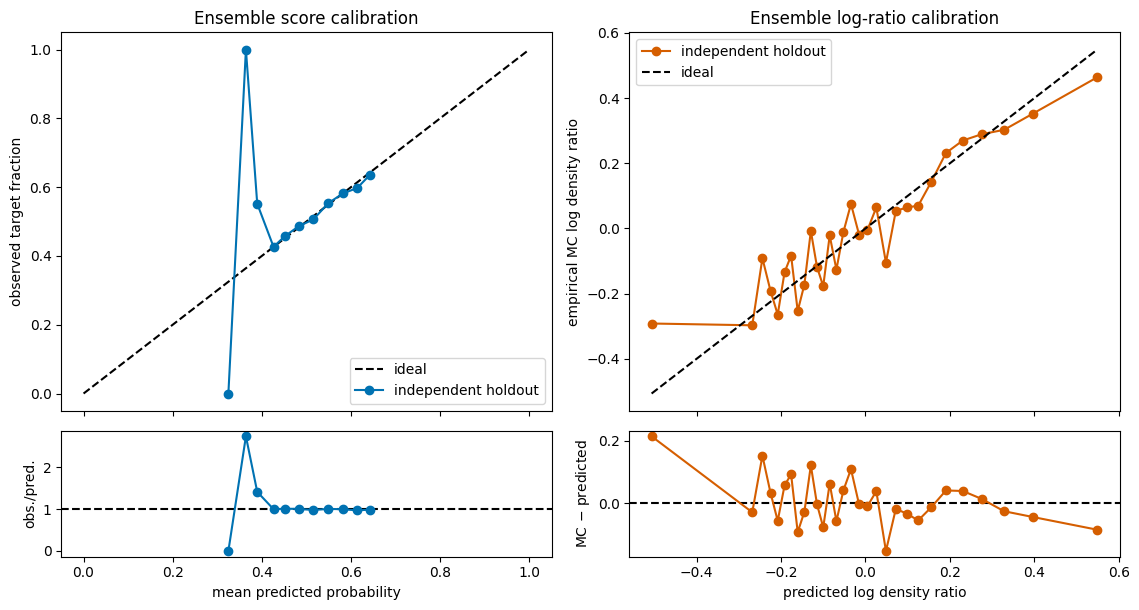

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/signal_reference_reweighting_x1.py


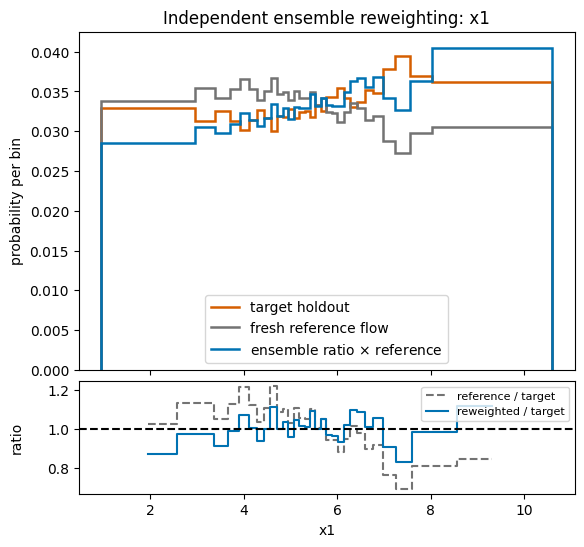

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/signal_reference_reweighting_x2.py


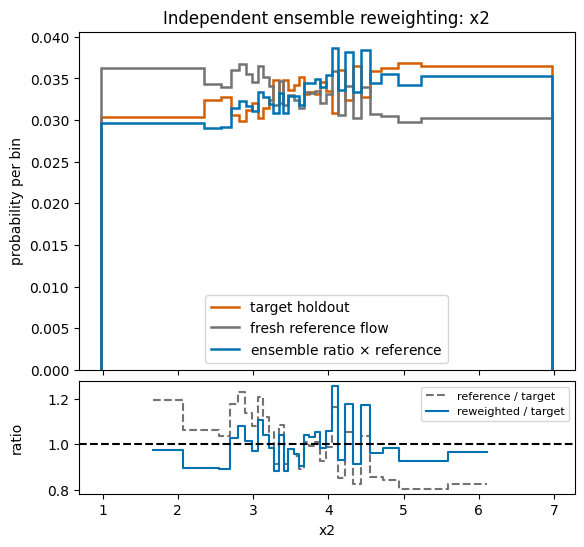

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/signal_reference_reweighting_x3.py


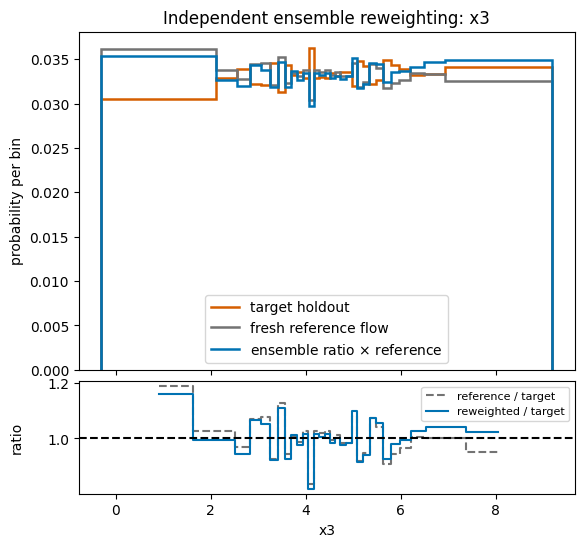

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/signal_reference_reweighting_x4.py


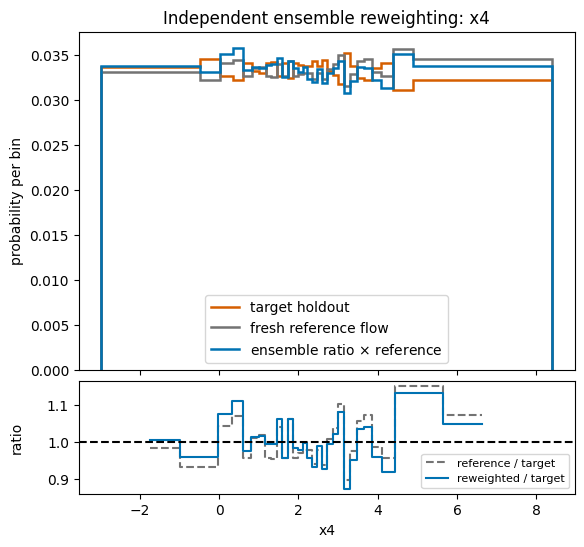

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/signal_reference_reweighting_x5.py


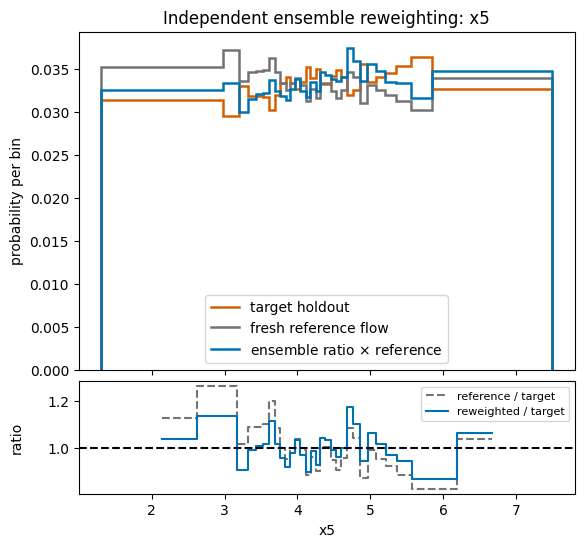

background {'classification': {'weighted_auc': 0.5585176343953479}, 'calibration': {'brier_score': 0.24676767692177687, 'expected_calibration_error': 0.007640430779069277, 'log_ratio_weighted_rmse': 0.0821509446438393, 'log_ratio_occupied_mass': 0.9999999999999998}, 'normalization': {'reference_mean_ratio': 1.003554201784417, 'reference_mean_standard_error': 0.0019356410785178755, 'reference_effective_events': 12301.000000000002, 'deployed_normalization': 0.9990794634400119}, 'validation': {'reference_count': 12301, 'source': 'explicit-target-holdout-and-fresh-reference-flow', 'target_count': 12301}}
Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/background_reference_ratio_calibration.py


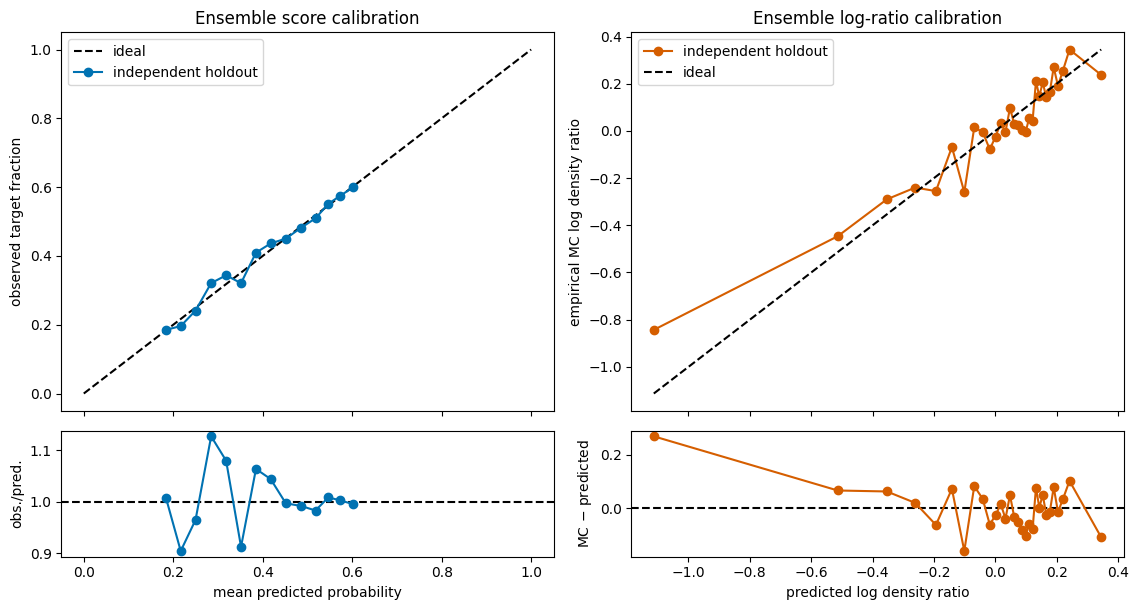

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/background_reference_reweighting_x1.py


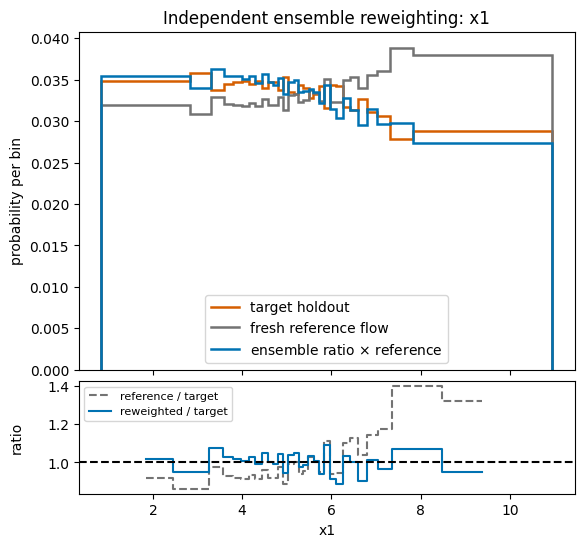

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/background_reference_reweighting_x2.py


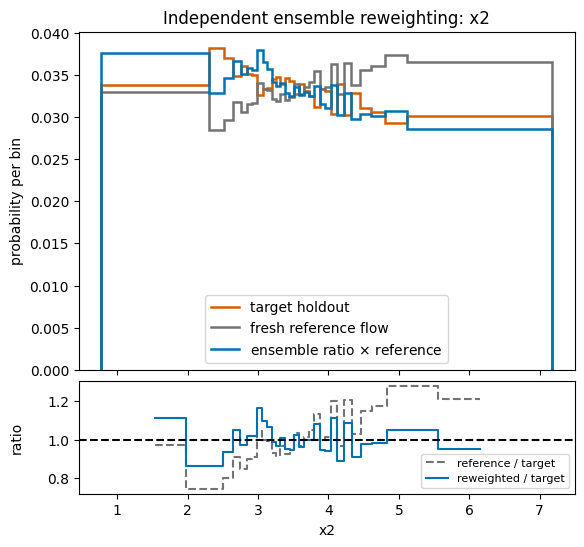

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/background_reference_reweighting_x3.py


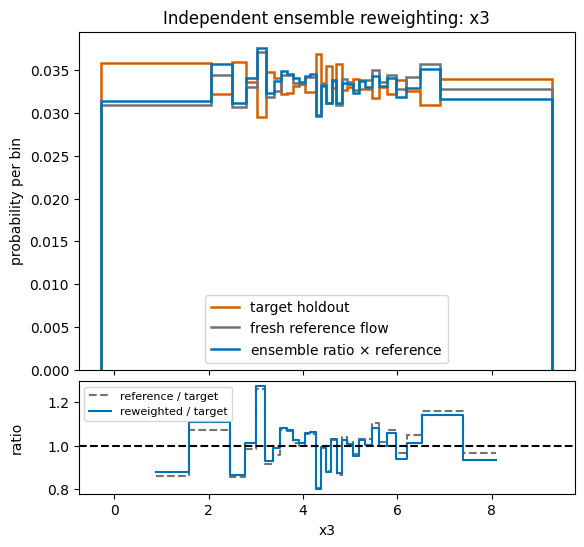

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/background_reference_reweighting_x4.py


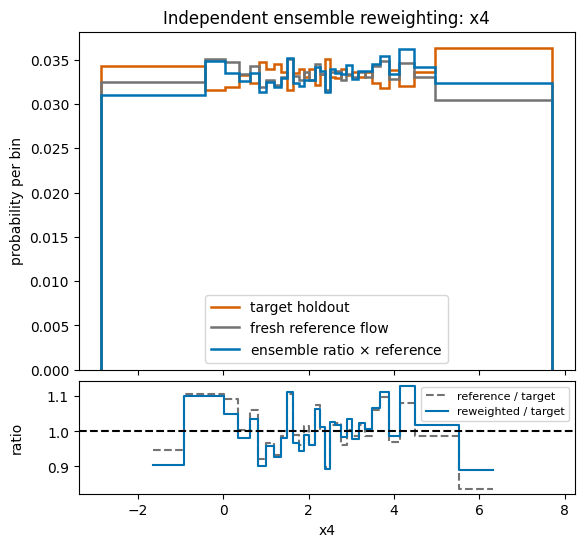

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/background_reference_reweighting_x5.py


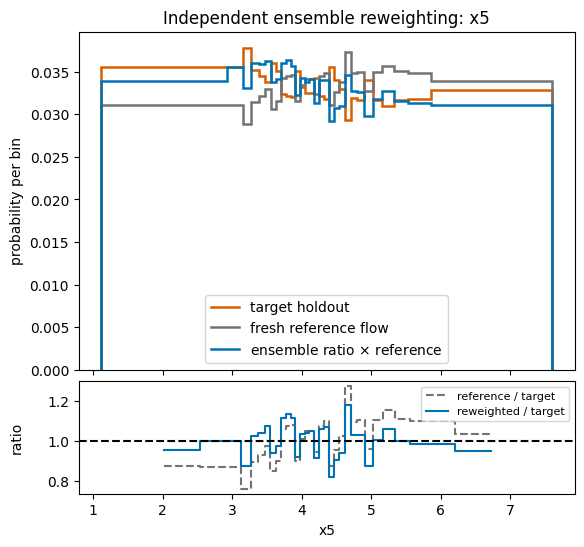

In [6]:
from hnsbi.ratio_diagnostics import (
    plot_ratio_validation_calibration,
    plot_ratio_validation_reweighting,
)

for sample in ('signal', 'background'):
    report = ratio_artifacts.diagnostics[sample]
    print(sample, report.metrics)
    fig = plot_ratio_validation_calibration(report)
    export_hybrid_figure(fig, f'{sample}_reference_ratio_calibration')
    plt.show()
    for feature in FEATURES:
        fig = plot_ratio_validation_reweighting(report, feature)
        export_hybrid_figure(
            fig,
            f'{sample}_reference_reweighting_{feature}',
        )
        plt.show()


## Weighted-reference joint closure

One-dimensional reweighting can look good while correlations remain wrong. The following ensemble-level pair plots compare the held-out process samples with fresh reference-flow events weighted by the normalized process ratio.


Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/weighted_reference_signal_pair_closure.py


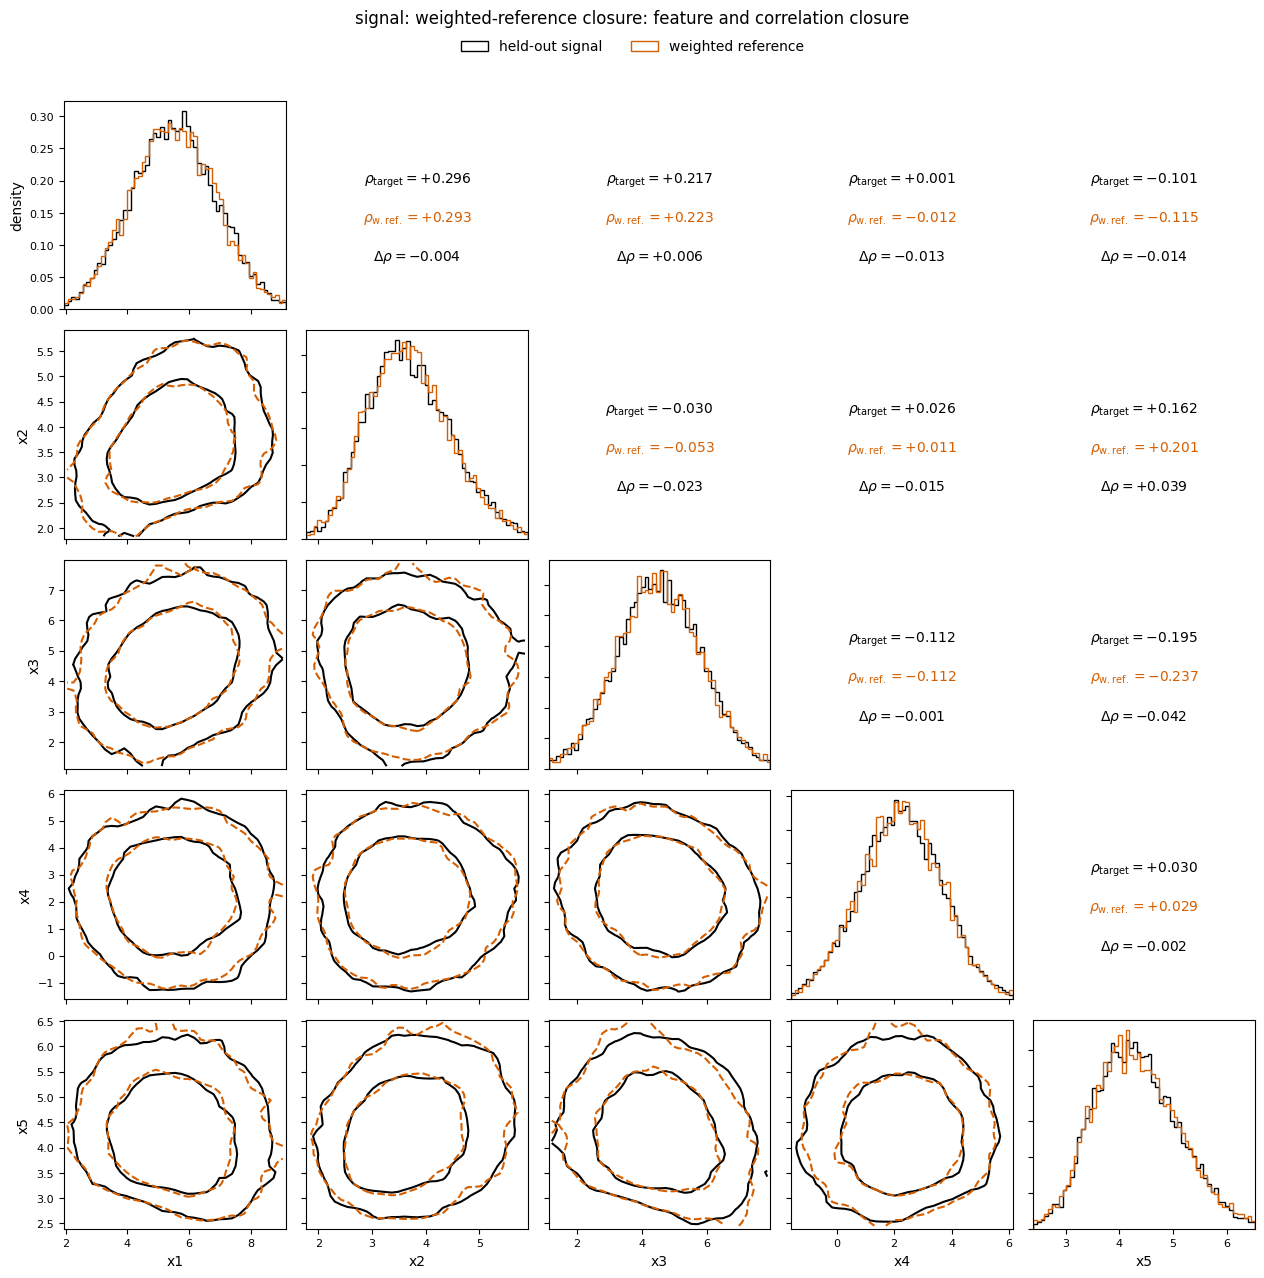

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/weighted_reference_background_pair_closure.py


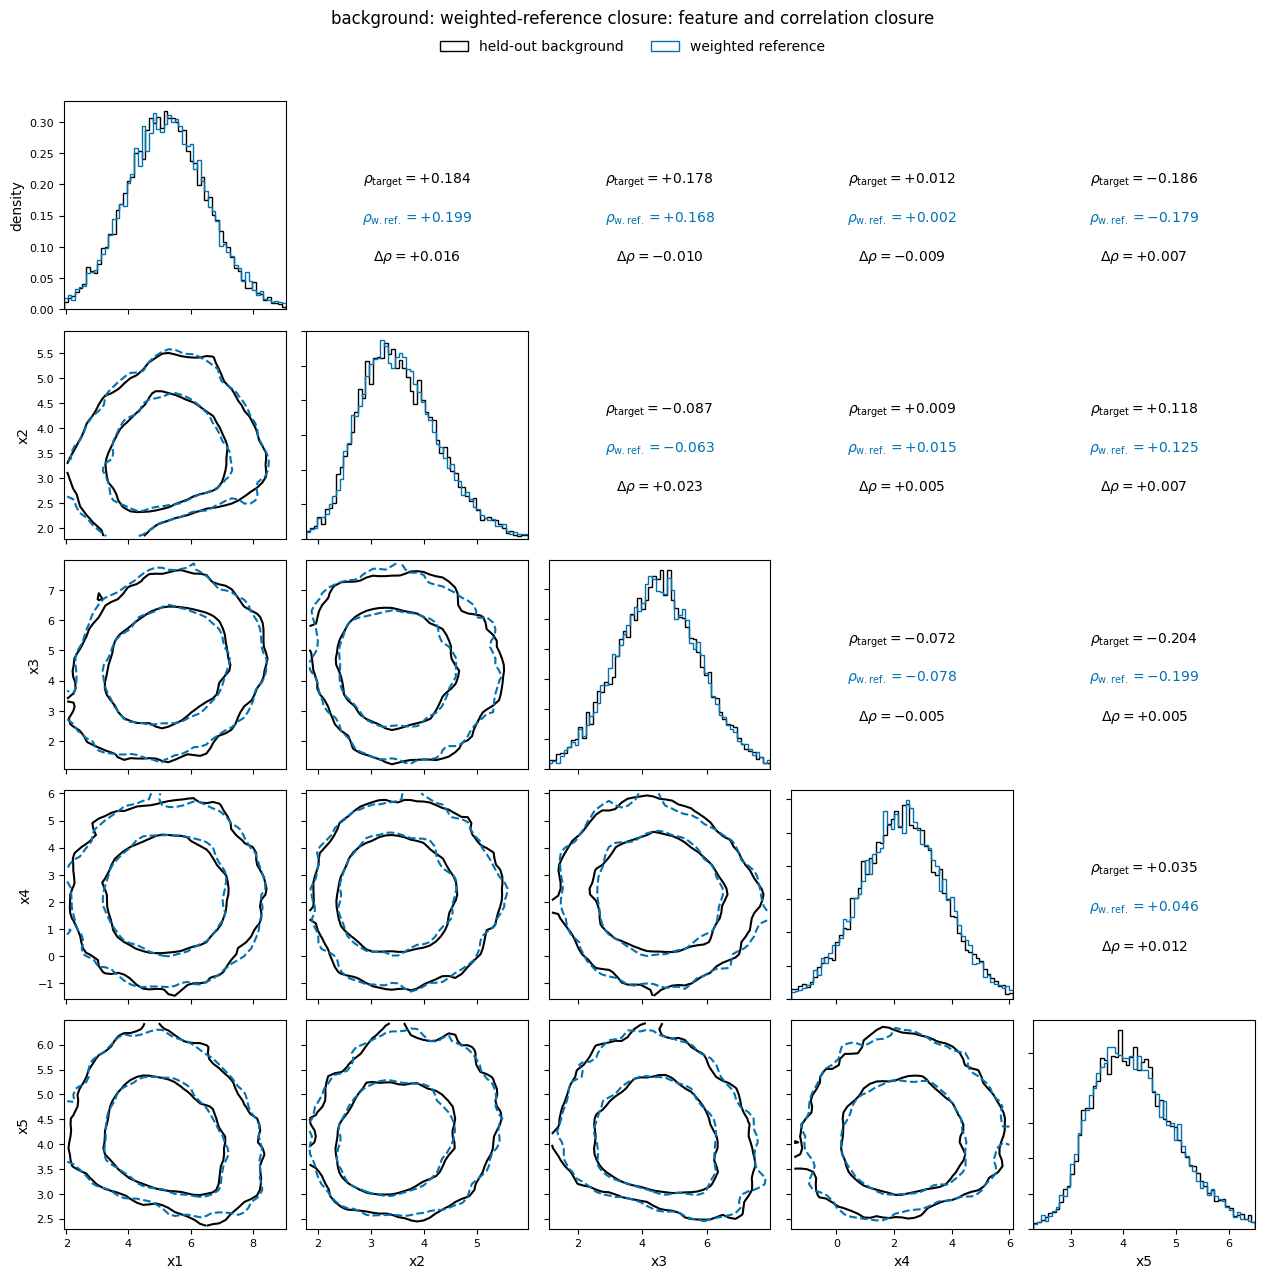

In [7]:
rng = np.random.default_rng(20260730)
heldout = {}
sample_specs = {
    sample['name']: sample
    for sample in project.config.frequentist['samples']
}
for sample, data_source in project.sample_sources().items():
    batch = data_source.materialize()
    split_column = sample_specs[sample]['source']['split_column']
    mask = np.asarray(batch.columns[split_column]).astype(str) == 'holdout'
    values = batch.values[mask]
    weights = batch.weights[mask]
    if not len(values):
        raise RuntimeError(f'No explicit holdout events for {sample}.')
    heldout[sample] = (values, weights)

for sample, color in (
    ('signal', SIGNAL_COLOR),
    ('background', BACKGROUND_COLOR),
):
    target_values, target_weights = heldout[sample]
    count = min(30_000, len(target_values))
    target_indices = rng.choice(len(target_values), count, replace=False)
    reference_validation = reference.sample(count, rng=rng)
    reference_weights = (
        ratio_artifacts.evaluators[sample](reference_validation)
        / ratio_artifacts.normalizer.means[sample]
    )
    fig = plot_flow_pair_closure(
        f'{sample}: weighted-reference closure',
        target_values[target_indices],
        reference_validation,
        FEATURES,
        mc_weights=target_weights[target_indices],
        generated_weights=reference_weights,
        mc_label=f'held-out {sample}',
        generated_label='weighted reference',
        generated_color=color,
        correlation_names=('target', 'w.ref.'),
    )
    export_hybrid_figure(
        fig,
        f'weighted_reference_{sample}_pair_closure',
    )
    plt.show()


## Reconstructed hybrid densities versus analytical truth

On the combined held-out selected signal and background support we now test the full hybrid conditional density,

$$
\log\widehat p_k(x)=\log q_\phi(x)
+\log\widehat r_k(x)-\log E_{q_\phi}[\widehat r_k].
$$

This is stricter than marginal reweighting: it exposes local density bias directly.


background: corr(log p)=0.9910, RMSE=0.2049, bias=-0.0165
Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/hybrid_background_log_density_truth_scatter.py


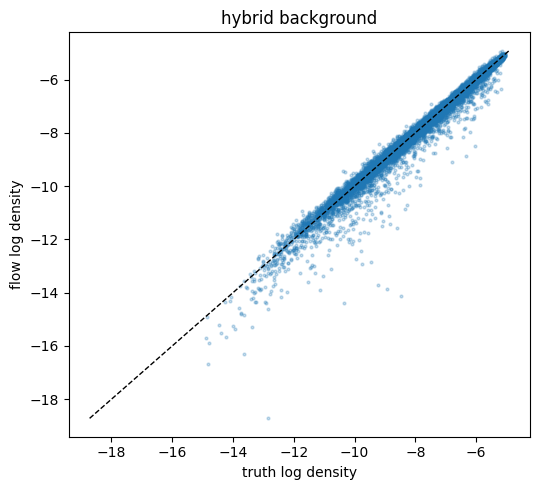

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/hybrid_background_log_density_truth_binned.py


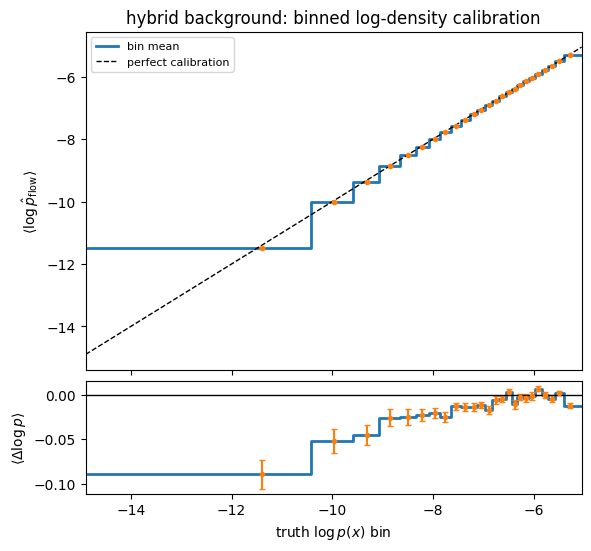

signal: corr(log p)=0.9912, RMSE=0.1892, bias=-0.0223
Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/hybrid_signal_log_density_truth_scatter.py


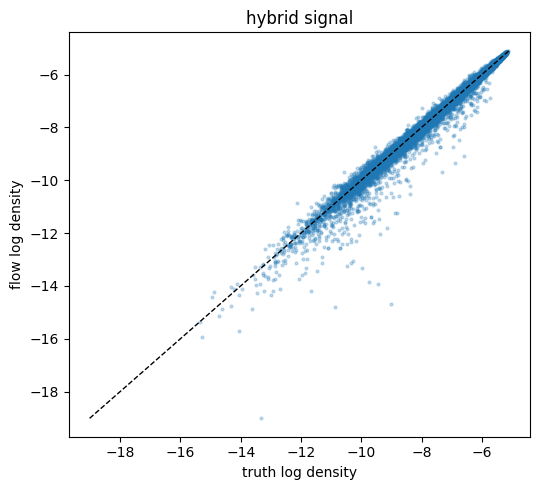

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/hybrid_signal_log_density_truth_binned.py


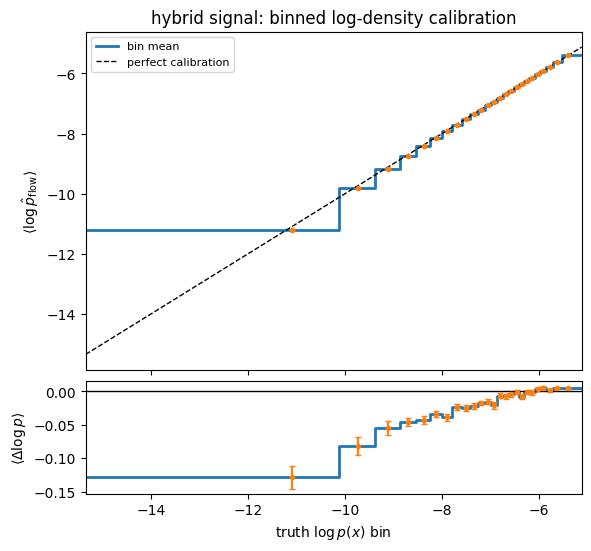

In [8]:
validation_values = np.concatenate(
    [heldout['background'][0], heldout['signal'][0]],
    axis=0,
)
physical_weights = []
for sample in ('background', 'signal'):
    _, weights = heldout[sample]
    physical_weights.append(
        weights * ANALYSIS_YIELDS[sample] / np.sum(weights)
    )
validation_weights = np.concatenate(physical_weights)

truth_log_densities = {
    sample: conditional_log_density(
        mixture_log_density(validation_values, components),
        selection_efficiency=SELECTION_EFFICIENCIES[sample],
    )
    for sample, components in RECO_COMPONENTS.items()
}
learned_reference = reference.log_prob(validation_values)
hybrid_log_densities = {}
for sample in ('signal', 'background'):
    normalized_ratio = (
        ratio_artifacts.evaluators[sample](validation_values)
        / ratio_artifacts.normalizer.means[sample]
    )
    hybrid_log_densities[sample] = (
        learned_reference
        + np.log(np.maximum(normalized_ratio, np.finfo(float).tiny))
    )

for sample in ('background', 'signal'):
    delta = hybrid_log_densities[sample] - truth_log_densities[sample]
    print(
        f'{sample}: '
        f'corr(log p)={np.corrcoef(truth_log_densities[sample], hybrid_log_densities[sample])[0, 1]:.4f}, '
        f'RMSE={np.sqrt(np.mean(delta**2)):.4f}, '
        f'bias={np.mean(delta):+.4f}'
    )
    fig = plot_log_density_truth_scatter(
        f'hybrid {sample}',
        truth_log_densities[sample],
        hybrid_log_densities[sample],
    )
    export_hybrid_figure(
        fig,
        f'hybrid_{sample}_log_density_truth_scatter',
    )
    plt.show()

    calibration, edges = binned_log_density_calibration(
        truth_log_densities[sample],
        hybrid_log_densities[sample],
    )
    fig = plot_log_density_truth_binned(
        f'hybrid {sample}',
        calibration,
        edges,
        truth_log_densities[sample],
        hybrid_log_densities[sample],
    )
    export_hybrid_figure(
        fig,
        f'hybrid_{sample}_log_density_truth_binned',
    )
    plt.show()


## Nominal likelihood closure

> Add blockquote



Before adding nuisances, compare the learned and analytical reconstructed densities on exactly the same physical held-out Asimov measure. This one-dimensional scan fixes all nuisances at their nominal values; the next section separately profiles the complete configured workspace.


grid minima: hybrid mu=0.400; analytic mu=1.500
Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/hybrid_vs_analytic_profile_likelihood.py


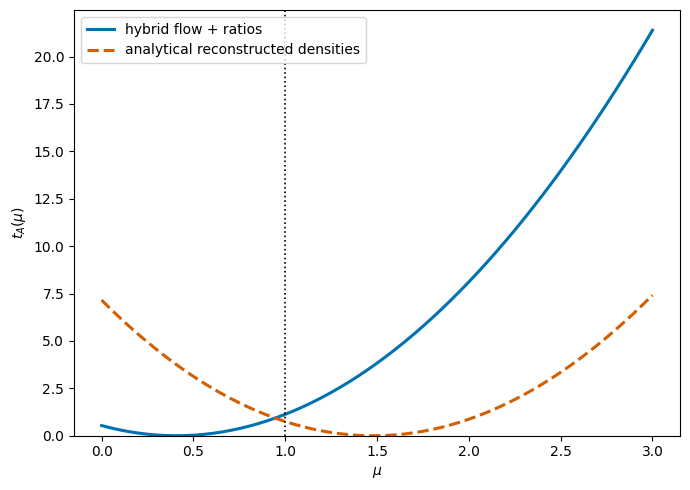

In [9]:
mu_grid = np.linspace(0.0, 3.0, 61)
hybrid_nominal_scan = extended_mu_scan(
    signal_log_density=hybrid_log_densities['signal'],
    background_log_density=hybrid_log_densities['background'],
    event_weights=validation_weights,
    signal_yield=ANALYSIS_YIELDS['signal'],
    background_yield=ANALYSIS_YIELDS['background'],
    mu_values=mu_grid,
)
truth_nominal_scan = extended_mu_scan(
    signal_log_density=truth_log_densities['signal'],
    background_log_density=truth_log_densities['background'],
    event_weights=validation_weights,
    signal_yield=ANALYSIS_YIELDS['signal'],
    background_yield=ANALYSIS_YIELDS['background'],
    mu_values=mu_grid,
)
print(
    f"grid minima: hybrid mu={mu_grid[np.argmin(hybrid_nominal_scan)]:.3f}; "
    f"analytic mu={mu_grid[np.argmin(truth_nominal_scan)]:.3f}"
)

fig, axis = plt.subplots(figsize=(7.0, 5.0))
axis.plot(
    mu_grid,
    hybrid_nominal_scan,
    color=BACKGROUND_COLOR,
    lw=2.2,
    label='hybrid flow + ratios',
)
axis.plot(
    mu_grid,
    truth_nominal_scan,
    color=SIGNAL_COLOR,
    lw=2.2,
    ls='--',
    label='analytical reconstructed densities',
)
axis.axvline(1.0, color='black', ls=':', lw=1.2)
axis.set(xlabel=r'$\mu$', ylabel=r'$t_A(\mu)$', ylim=(0, None))
axis.legend()
fig.tight_layout()
export_hybrid_figure(fig, 'hybrid_vs_analytic_profile_likelihood')
plt.show()


## Full systematics-profiled workspace

The final scan adds the response, resolution, and signal-theory morphs from YAML, writes the authenticated JSON workspace, fits with JAX derivatives and iminuit, and profiles all three nuisances at each fixed $\mu$.


raw count / ESS: 50000 47754.48320220762
{'mu': 1.0, 'response': 0.0, 'resolution': 0.0, 'theory': 0.0} {'mu': 0.6552619983919771, 'response': 0.004821543197594862, 'resolution': 0.008860977055361123, 'theory': 0.8181990352296594}
Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/full_systematics_profile_scan.py


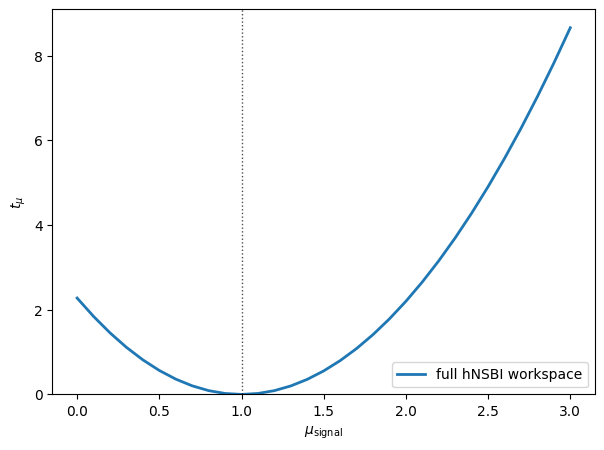

In [10]:
from hnsbi.inference import MinuitInference

systematic_training = project.train_systematics()
runtime_systematics = project.build_runtime_systematics(
    systematic_training
)
asimov = project.build_configured_asimov(
    reference=reference,
    ratios=ratio_artifacts.evaluators,
    normalizer=ratio_artifacts.normalizer,
    systematics=runtime_systematics,
)
workspace = project.write_configured_workspace(
    asimov,
    reference_manifest=reference_artifacts.checkpoint_manifest,
    ratio_manifests={
        name: value.manifest_path
        for name, value in ratio_artifacts.training.items()
    },
)
likelihood = project.workspace_runtime(workspace.path)
inference = MinuitInference(likelihood)
fit = inference.fit()
if not fit.success:
    raise RuntimeError(f'Global fit failed: {fit.message}')
print('raw count / ESS:', asimov.raw_count, asimov.ess)
print(fit.point, fit.errors)

profiled_scan = inference.profile_scan(
    'mu',
    np.linspace(0.0, 3.0, 31),
    initial=fit.point,
)
fig = plot_profile_scan(
    profiled_scan.values,
    profiled_scan.twice_delta_nll,
    label='full hNSBI workspace',
)
export_hybrid_figure(fig, 'full_systematics_profile_scan')
plt.show()


## Nominal toy closure

Check bounded fits with pseudo-experiments. An exact toy in the selected example still contains roughly 150,000 background events, so the default visualization compresses the nominal likelihood along its sufficient process ratio

$$
q(x)=\frac{\nu_S p_S(x)}{\nu_B p_B(x)}.
$$

Counts in the resulting bins are still independent Poisson draws; only the one-dimensional ratio is binned. The cell first checks the compressed Asimov curve against the unbinned learned-model curve on the same support, then reproduces the $t_\mu$, $\hat\mu$, and Asimov/Wald-versus-toy plots. `quick` runs 5,000 toys per hypothesis; `paper` restores the 100,000-toy study. Nuisances are fixed here, as in the original toy figures; the full LHC example separately exposes authenticated nuisance-aware native toys.


compressed ratio bins: 512
q0,A compression difference on common support: -0.000%


mu_hat                t_mu              q_zero            \
             mean       std      mean       std      mean       std   
mu_true                                                               
0.0      0.224525  0.327649  0.510807  1.147317  0.510807  1.147317   
1.0      1.012382  0.540964  0.985909  1.328219  4.259508  3.875997   

            n_events              
                mean         std  
mu_true                           
0.0      154803.4948  396.651133  
1.0      155414.9482  392.601657

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/toy_test_statistic_distributions.py


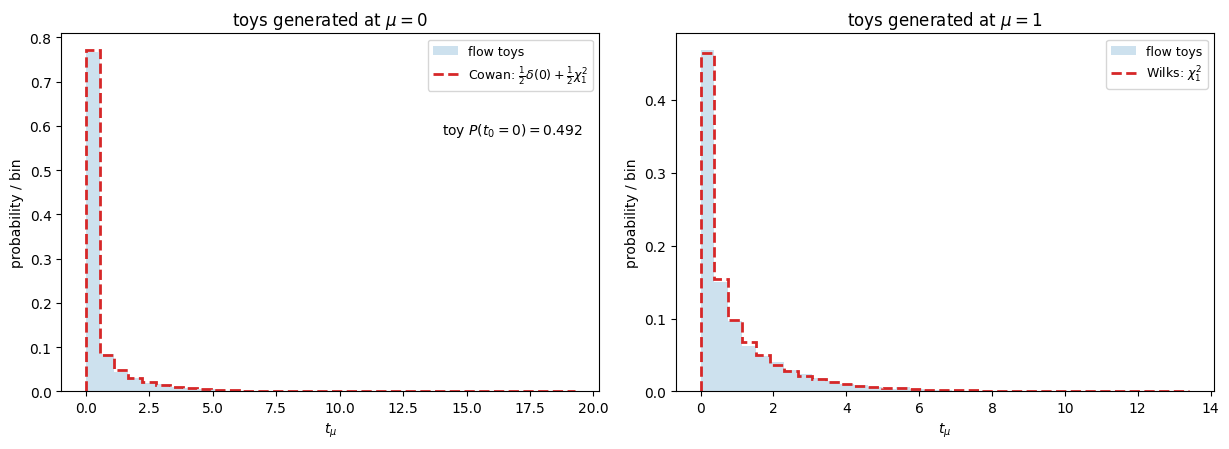

Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/toy_signal_strength_distributions.py


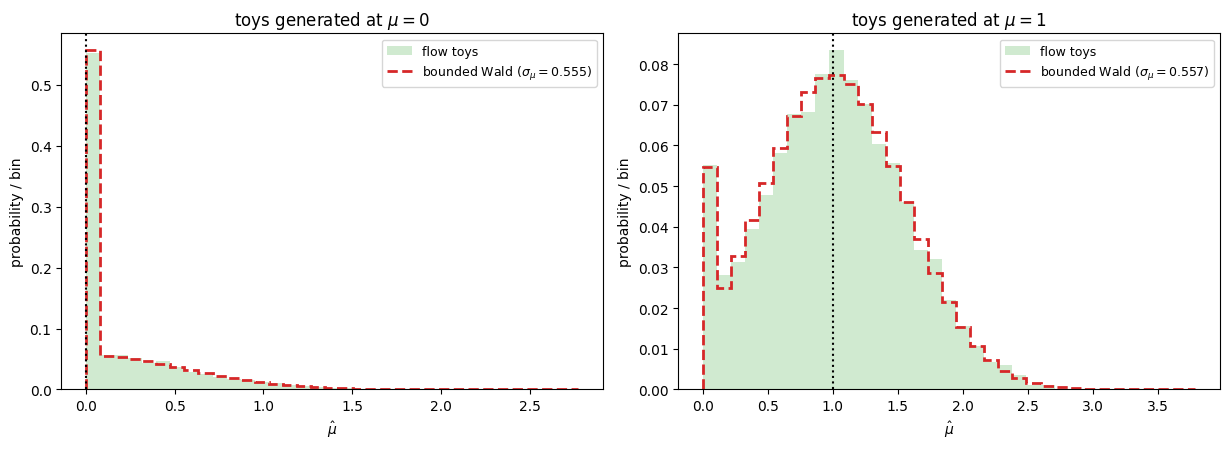

In [11]:
from scipy.stats import ncx2, norm

from utils_lhc_validation import (
    build_compressed_toy_model,
    run_compressed_toys,
)
from utils_plotting import plot_mu_hat_toys, plot_t_mu_toys

TOY_PROFILE = 'quick'  # 'quick' or 'paper'
N_TOYS = 100_000 if TOY_PROFILE == 'paper' else 5_000
TOY_BINS = 512
TOY_HYPOTHESES = (0.0, 1.0)
TOY_PLOT_BINS = 35

toy_rng = np.random.default_rng(20260810)
toy_support = reference.sample(100_000, rng=toy_rng)
toy_signal_ratio = (
    ratio_artifacts.evaluators['signal'](toy_support)
    / ratio_artifacts.normalizer.means['signal']
)
toy_background_ratio = (
    ratio_artifacts.evaluators['background'](toy_support)
    / ratio_artifacts.normalizer.means['background']
)
# Use a common-support normalization for the compression comparison.
toy_signal_ratio /= np.mean(toy_signal_ratio)
toy_background_ratio /= np.mean(toy_background_ratio)
toy_truth_weights = (
    ANALYSIS_YIELDS['signal'] * toy_signal_ratio
    + ANALYSIS_YIELDS['background'] * toy_background_ratio
) / len(toy_support)
uncompressed_toy_support_scan = extended_mu_scan(
    signal_log_density=np.log(
        np.maximum(toy_signal_ratio, np.finfo(float).tiny)
    ),
    background_log_density=np.log(
        np.maximum(toy_background_ratio, np.finfo(float).tiny)
    ),
    event_weights=toy_truth_weights,
    signal_yield=ANALYSIS_YIELDS['signal'],
    background_yield=ANALYSIS_YIELDS['background'],
    mu_values=mu_grid,
)
compressed_toy_model = build_compressed_toy_model(
    toy_signal_ratio,
    toy_background_ratio,
    signal_yield=ANALYSIS_YIELDS['signal'],
    background_yield=ANALYSIS_YIELDS['background'],
    bins=TOY_BINS,
)
compressed_asimov_scan = compressed_toy_model.asimov_scan(mu_grid)
compression_difference = (
    compressed_asimov_scan[0] / uncompressed_toy_support_scan[0] - 1.0
)
print(f'compressed ratio bins: {compressed_toy_model.bins:,}')
print(
    'q0,A compression difference on common support: '
    f'{compression_difference:+.3%}'
)
if abs(compression_difference) > 0.01:
    raise RuntimeError(
        'The ratio compression changes q0,A by more than 1%; '
        'increase TOY_BINS before interpreting the toy figures.'
    )

toy_results = run_compressed_toys(
    compressed_toy_model,
    hypotheses=TOY_HYPOTHESES,
    n_toys=N_TOYS,
    seed=314159,
    batch_size=1_000,
)
sigma_by_mu = {
    float(mu_true): 1.0 / np.sqrt(float(group['information'].mean()))
    for mu_true, group in toy_results.groupby('mu_true')
}
display(
    toy_results.groupby('mu_true')[
        ['mu_hat', 't_mu', 'q_zero', 'n_events']
    ].agg(['mean', 'std'])
)

fig = plot_t_mu_toys(toy_results, n_bins=TOY_PLOT_BINS)
export_hybrid_figure(fig, 'toy_test_statistic_distributions')
plt.show()

fig = plot_mu_hat_toys(
    toy_results,
    sigma_by_mu,
    n_bins=TOY_PLOT_BINS,
)
export_hybrid_figure(fig, 'toy_signal_strength_distributions')
plt.show()


Asimov sigma_mu: 0.557315
Toy std(mu_hat): 0.540964
Asimov q0,A: 3.237011
Wrote standalone figure script: /content/drive/MyDrive/hsbi-toolkit/hnsbi-toolkit/examples/lhc_analysis/artifacts/notebook_figures/hybrid/scripts/asimov_prediction_vs_toys.py


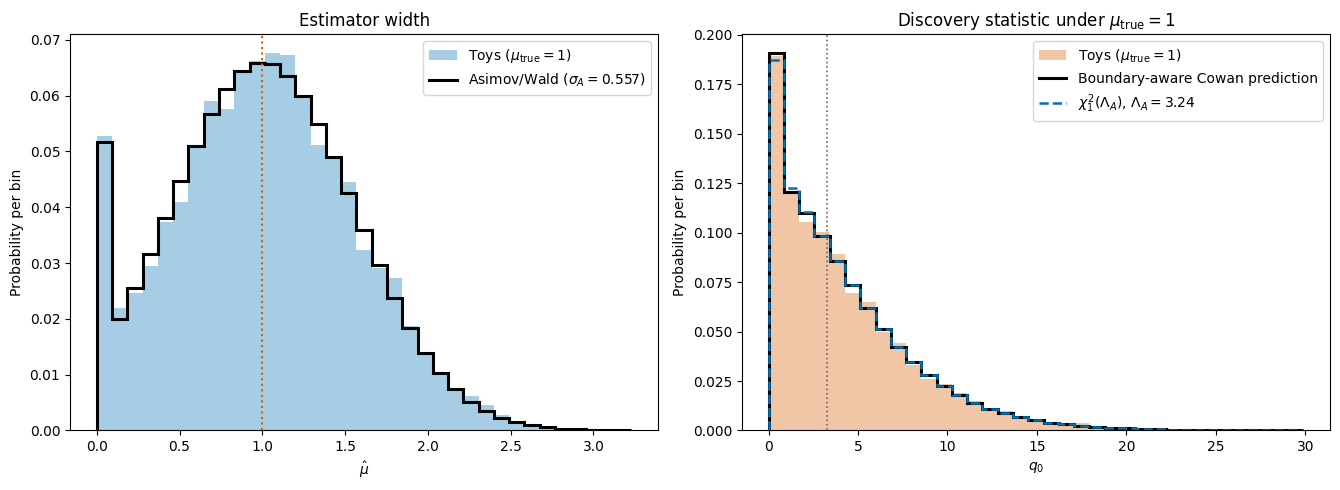

In [12]:
truth_mu = 1.0
truth_toys = toy_results[toy_results['mu_true'] == truth_mu]
mu_hat_toys = truth_toys['mu_hat'].to_numpy(dtype=np.float64)
q_zero_toys = truth_toys['q_zero'].to_numpy(dtype=np.float64)
expected_counts = (
    truth_mu
    * compressed_toy_model.signal_yield
    * compressed_toy_model.signal_probability
    + compressed_toy_model.background_yield
    * compressed_toy_model.background_probability
)
response = compressed_toy_model.signal_over_background / (
    1.0
    + truth_mu * compressed_toy_model.signal_over_background
)
asimov_sigma = 1.0 / np.sqrt(np.sum(expected_counts * response**2))
asimov_q_zero = float(compressed_toy_model.asimov_scan([0.0])[0])
print(f'Asimov sigma_mu: {asimov_sigma:.6f}')
print(f'Toy std(mu_hat): {np.std(mu_hat_toys, ddof=1):.6f}')
print(f'Asimov q0,A: {asimov_q_zero:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
mu_upper = max(
    float(np.max(mu_hat_toys)) * 1.001,
    truth_mu + 4.0 * asimov_sigma,
    1.25,
)
mu_edges = np.linspace(0.0, mu_upper, TOY_PLOT_BINS + 1)
mu_toy_probability = (
    np.histogram(mu_hat_toys, bins=mu_edges)[0] / len(mu_hat_toys)
)
mu_gaussian_cdf = norm.cdf((mu_edges - truth_mu) / asimov_sigma)
mu_asimov_probability = np.diff(mu_gaussian_cdf)
mu_asimov_probability[0] += mu_gaussian_cdf[0]
axes[0].stairs(
    mu_toy_probability,
    mu_edges,
    fill=True,
    alpha=0.35,
    color=BACKGROUND_COLOR,
    label=rf'Toys ($\mu_{{\rm true}}={truth_mu:g}$)',
)
axes[0].stairs(
    mu_asimov_probability,
    mu_edges,
    lw=2.2,
    color='black',
    label=rf'Asimov/Wald ($\sigma_A={asimov_sigma:.3f}$)',
)
axes[0].axvline(truth_mu, color=SIGNAL_COLOR, ls=':', lw=1.5)
axes[0].set(
    xlabel=r'$\hat\mu$',
    ylabel='Probability per bin',
    title='Estimator width',
)
axes[0].legend()

q_upper = max(
    float(np.max(q_zero_toys)) * 1.001,
    float(ncx2.ppf(0.999, df=1, nc=asimov_q_zero)),
    1.0,
)
q_edges = np.linspace(0.0, q_upper, TOY_PLOT_BINS + 1)
q_toy_probability = (
    np.histogram(q_zero_toys, bins=q_edges)[0] / len(q_zero_toys)
)
q_ncx2_probability = np.diff(
    ncx2.cdf(q_edges, df=1, nc=asimov_q_zero)
)
q_boundary_cdf = norm.cdf(np.sqrt(q_edges) - np.sqrt(asimov_q_zero))
q_boundary_probability = np.diff(q_boundary_cdf)
q_boundary_probability[0] += q_boundary_cdf[0]
axes[1].stairs(
    q_toy_probability,
    q_edges,
    fill=True,
    alpha=0.35,
    color=SIGNAL_COLOR,
    label=rf'Toys ($\mu_{{\rm true}}={truth_mu:g}$)',
)
axes[1].stairs(
    q_boundary_probability,
    q_edges,
    lw=2.2,
    color='black',
    label='Boundary-aware Cowan prediction',
)
axes[1].stairs(
    q_ncx2_probability,
    q_edges,
    lw=1.8,
    ls='--',
    color=BACKGROUND_COLOR,
    label=rf'$\chi^2_1(\Lambda_A)$, $\Lambda_A={asimov_q_zero:.2f}$',
)
axes[1].axvline(asimov_q_zero, color='0.4', ls=':', lw=1.2)
axes[1].set(
    xlabel=r'$q_0$',
    ylabel='Probability per bin',
    title=r'Discovery statistic under $\mu_{\rm true}=1$',
)
axes[1].legend()
fig.tight_layout()
export_hybrid_figure(fig, 'asimov_prediction_vs_toys')
plt.show()
